# analysis

## imports

In [173]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [174]:
import sys
import os
sys.path.append(f'{os.getcwd()}/irc_gym')

In [175]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForaging as AF
from auditoryforage.AF_env import AuditoryForagingReward as AFR
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2
from stable_baselines3 import PPO
from irc_gym.irc.model import FuncBeliefModel
from multiprocessing import Pool
import multiprocessing as mp
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict
import seaborn as sns
import multiprocessing
from ult import *

## settings

In [176]:
food_reward_list = food_reward_list = np.linspace(10, 9999, 5)
env_param = [-10, 1500, 0.087213, .25, -50, -10, 0]

task = AFR2(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
num_epochs = 1
task.food_reward_list = food_reward_list

taskbelief = FuncBeliefModel(env=task, rng=1)

agent=PPO.load('ycstore/seed_0_date_16_periodic_e3_e5', device='cpu')
no_episodes = 22222

## collect data

In [177]:
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=agent,
                              num_steps=100000)
    return episode

with multiprocessing.Pool(processes=27) as pool:
    all_episode_data = pool.map(eval_wrapper, range(no_episodes))

In [178]:
def process_one_episode_wrapper(episode):
    return process_one_episode(episode, task)
with multiprocessing.Pool(processes=27) as pool:
    results = pool.map(process_one_episode_wrapper, all_episode_data)

In [179]:
# # run mp job
# def eval_wrapper(a):
#     episode = run_one_episode(task=task, taskbelief=taskbelief, agent=agent,num_steps=100000)
#     food_reward_idx,hit_count,miss_count,false_alarm_count,noise_time_before_lick,signal_time_before_lick,total_noise_time,total_signal_time,total_reward,attention_time_points_across_episodes,episode_length_across_episodes,hit_reaction_time_across_episodes,fa_reaction_time_across_episodes = process_one_episode(
#         episode, task)
#     return (food_reward_idx,
#             hit_count,
#             miss_count,
#             false_alarm_count,
#             noise_time_before_lick,
#             signal_time_before_lick,
#             total_noise_time,
#             total_signal_time,
#             total_reward,
#             attention_time_points_across_episodes,
#             episode_length_across_episodes,
#             hit_reaction_time_across_episodes,
#             fa_reaction_time_across_episodes
#             )


# with multiprocessing.Pool(processes=27) as pool:
#     results = pool.map(eval_wrapper, range(no_episodes))


## process data

In [180]:

# process the mp results
hit_count_list = [[0] for _ in range(len(food_reward_list))]
miss_count_list = [[0] for _ in range(len(food_reward_list))]
false_alarm_list = [[0] for _ in range(len(food_reward_list))]

noise_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
signal_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
total_noise_time_list = [[0] for _ in range(len(food_reward_list))]
total_signal_time_list = [[0] for _ in range(len(food_reward_list))]

# dist naming space: list of list of num. big list of each reward cond. small list of each trial's summary stats, which is a single number.
total_reward_dist= [[] for _ in range(len(food_reward_list))]
rt_hit_dist=[[] for _ in range(len(food_reward_list))]
rt_fa_dist=[[] for _ in range(len(food_reward_list))]
total_att_time_dist = [[] for _ in range(len(food_reward_list))]
for res in results:
    (food_reward_idx,
     hit_count,
     miss_count,
     false_alarm_count,

     noise_time_before_lick,
     signal_time_before_lick,
     total_noise_time,
     total_signal_time,

     total_reward,

     attention_time_points_across_episodes,
     episode_length_across_episodes,
     hit_reaction_time_across_episodes,
     fa_reaction_time_across_episodes
     ) = res

    hit_count_list[food_reward_idx][0] += (hit_count)
    miss_count_list[food_reward_idx][0] += (miss_count)
    false_alarm_list[food_reward_idx][0] += (false_alarm_count)

    noise_time_before_lick_list[food_reward_idx][0] += (noise_time_before_lick)
    signal_time_before_lick_list[food_reward_idx][0] += (
        signal_time_before_lick)
    total_noise_time_list[food_reward_idx][0] += (total_noise_time)
    total_signal_time_list[food_reward_idx][0] += (total_signal_time)

    total_reward_dist[food_reward_idx].append(total_reward)
    rt_hit_dist[food_reward_idx].append(signal_time_before_lick)
    rt_fa_dist[food_reward_idx].append(noise_time_before_lick)
    total_att_time_dist[food_reward_idx].append(len(attention_time_points_across_episodes[0]))

In [181]:
all_reward_res={} # k: v = foodreward idx: this food reward res
for r in range(len(food_reward_list)):
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len=[],[],[],[],[]
    all_reward_res[r]=attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len


for episode in all_episode_data:
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
    att_time_list.append(
        np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
    attention_prob, lick_prob = get_att_lick_probs(episode, agent)
    attention_prob_list.append(attention_prob)
    lick_prob_list.append(lick_prob)
    if episode['actions'][-1][0] == 1:
        lick_time_list.append(len(episode['states']))
    trial_len.append(len(episode['actions']))

# plots

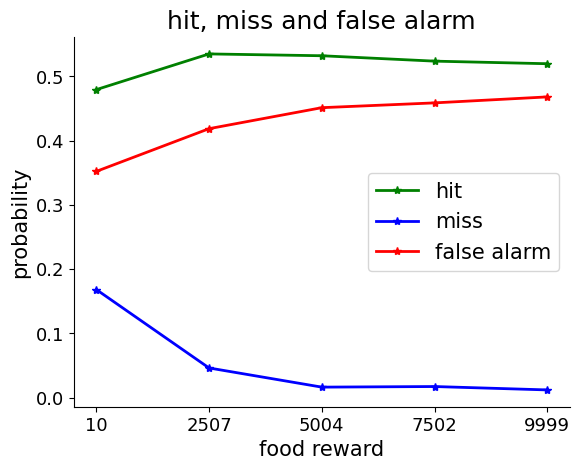

In [182]:
# figure 1
#n classic 3 color curve.
plot_hit_miss_FA(food_reward_list, hit_count_list, miss_count_list, false_alarm_list, 'hit, miss and false alarm')

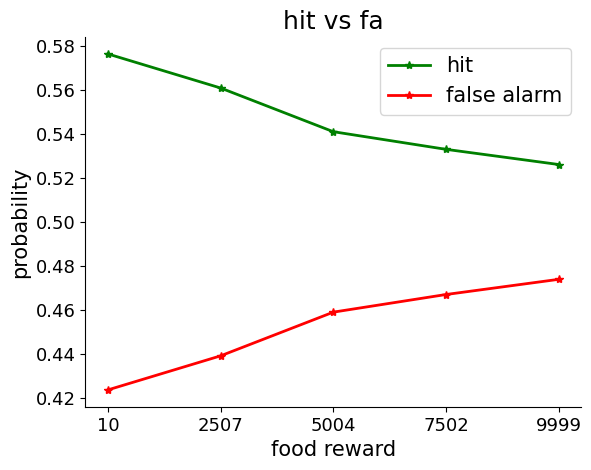

In [183]:
# figure 2
#  hit and fa curve.
plot_hit_fa(food_reward_list, hit_count_list, false_alarm_list, 'hit vs fa')
# extra, hit and miss
# plot_hit_miss(food_reward_list, hit_count_list, miss_count_list, 'hit vs miss')

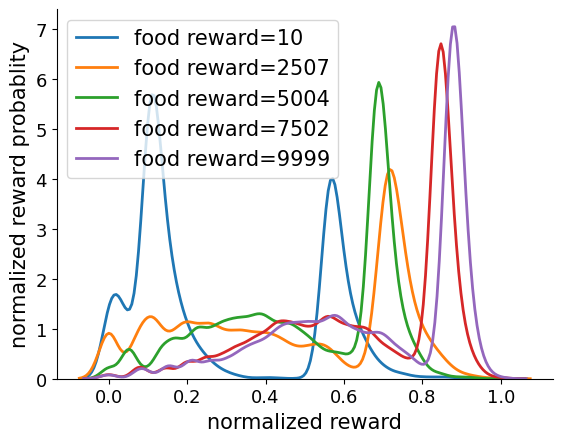

In [184]:
# figure 3, food reward distribution
for food_reward_idx, v in enumerate(total_reward_dist):
    v = (v - min(v)) / (max(v) - min(v))
    v = 1-v
    sns.kdeplot(v, fill=False, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=0.5,)
plt.ylabel('normalized reward probablity')
plt.xlabel('normalized reward')
plt.legend()
plt.show()


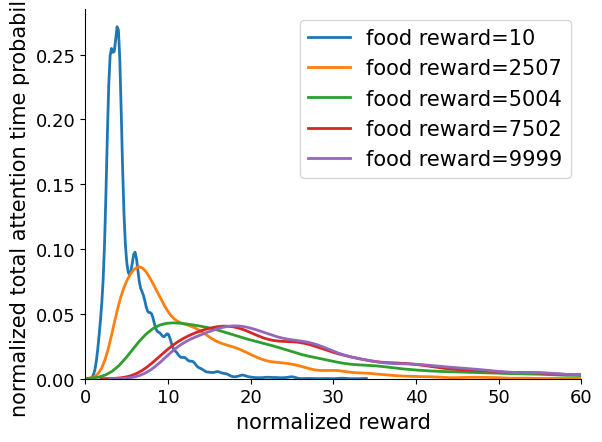

In [185]:
# figure 4
# total attention time in one trial distubition, similar to the reward distribution during training

for food_reward_idx, v in enumerate(total_att_time_dist):
    v = np.array(v)
    # ignore the 0 reaction time in the plots
    sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', clip=(0, np.max(v)), bw_adjust=0.7)
plt.xlim(0,60)
plt.ylabel('normalized total attention time probability')
plt.xlabel('normalized reward')
plt.legend()
plt.show()



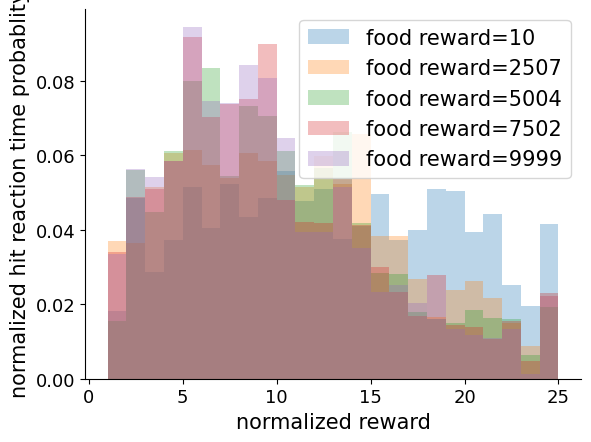

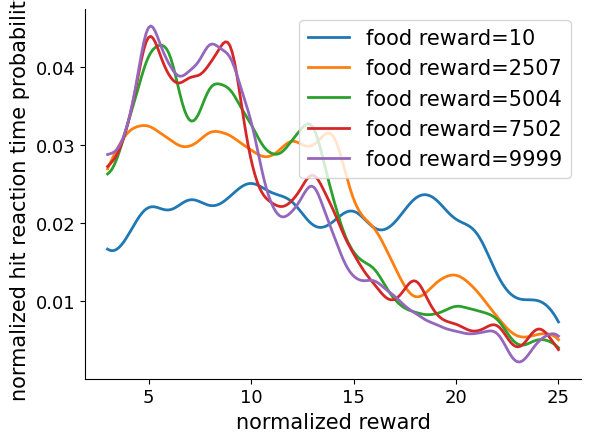

In [186]:

# figure 5
# reaction time distubition, similar to the reward distribution during training
for food_reward_idx, v in enumerate(rt_hit_dist):
    v=np.array(v)
    # ignore the 0 reaction time in the plots
    _=plt.hist(v, bins=np.arange(1, np.max(v) + 1), density=True, alpha=0.3, label=f'food reward={food_reward_list[food_reward_idx]:.0f}',)
plt.ylabel('normalized hit reaction time probablity')
plt.xlabel('normalized reward')
plt.legend()
plt.show()

# alt
for food_reward_idx, v in enumerate(rt_hit_dist):
    v = np.array(v)
    # ignore the 0 reaction time in the plots
    sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', clip=(3, np.max(v)), bw_adjust=0.5)

plt.ylabel('normalized hit reaction time probability')
plt.xlabel('normalized reward')
plt.legend()
plt.show()


## falase alarm reaction time
# for food_reward_idx, v in enumerate(rt_fa_dist):
#     v=np.array(v)
#     _=plt.hist(v, bins=np.arange(1, np.max(v) + 1), density=True, alpha=0.3, label=f'food reward={food_reward_list[food_reward_idx]:.0f}',)
# plt.ylabel('normalized fa reaction time probablity')
# plt.xlabel('normalized reward')
# plt.legend()
# plt.show()


# # alt
# for food_reward_idx, v in enumerate(rt_fa_dist):
#     v = np.array(v)
#     # ignore the 0 reaction time in the plots
#     sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', clip=(3, np.max(v)), bw_adjust=0.5)

# plt.ylabel('normalized hit reaction time probability')
# plt.xlabel('normalized reward')
# plt.legend()
# plt.show()




/tmp/ipykernel_925388/1316978792.py:13: RuntimeWarning: divide by zero encountered in divide
  plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)), label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
/tmp/ipykernel_925388/1316978792.py:13: RuntimeWarning: invalid value encountered in divide
  plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)), label=f'food reward={food_reward_list[food_reward_idx]:.0f}')


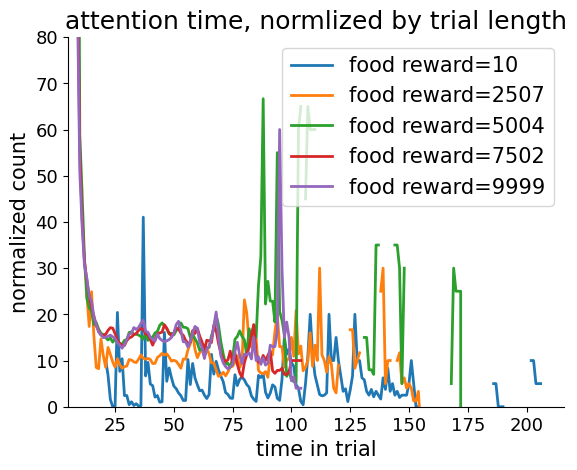

In [187]:
# added may1st, figure 6
plt.figure()
for food_reward_idx in all_reward_res.keys():
    
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len=all_reward_res[food_reward_idx]

    data=att_time_list        
    padded=pad_zero_attention(data)
    trial_count_i=count_less_equal_index(trial_len)
    
    # plt.plot(np.sum(padded, axis=0)*np.cumsum(trial_count_i))
    # plt.plot(np.sum(padded, axis=0)/(trial_count_i))
    plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)), label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
plt.xlabel('time in trial')
plt.ylabel('normalized count')
plt.title(f'attention time, normlized by trial length')
plt.ylim(0,80)
plt.xlim(5,None)
plt.legend()
plt.show()

/tmp/ipykernel_925388/204285521.py:12: RuntimeWarning: divide by zero encountered in divide
  plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)))
/tmp/ipykernel_925388/204285521.py:12: RuntimeWarning: invalid value encountered in divide
  plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)))


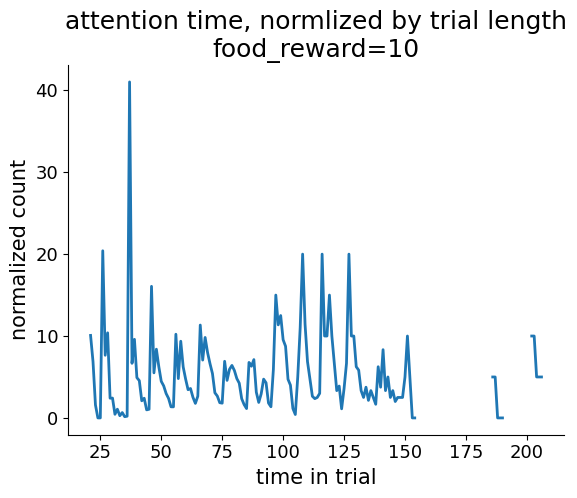

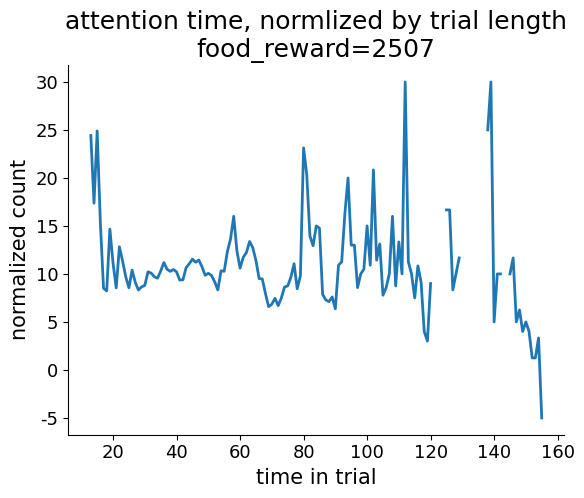

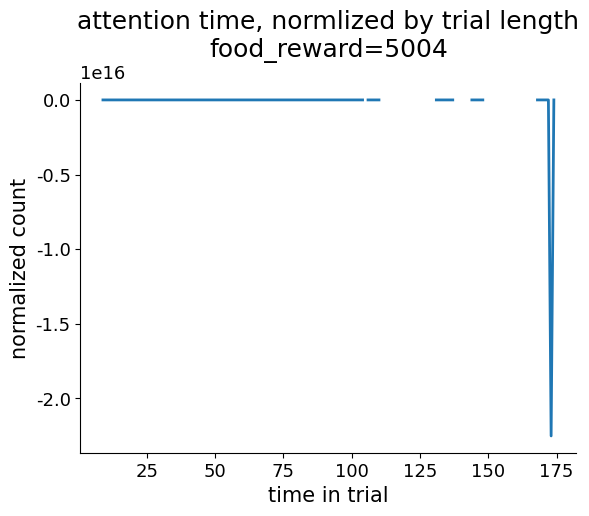

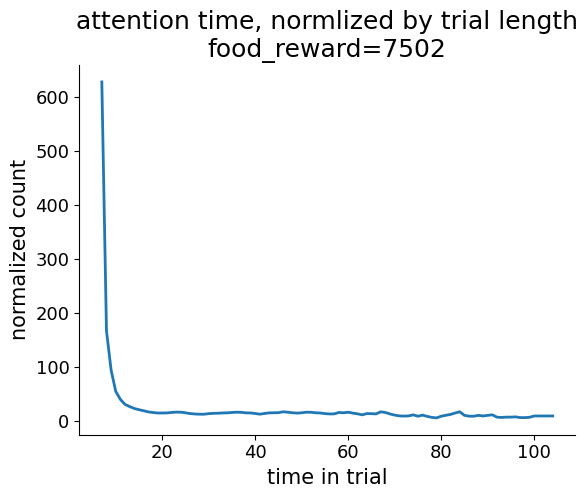

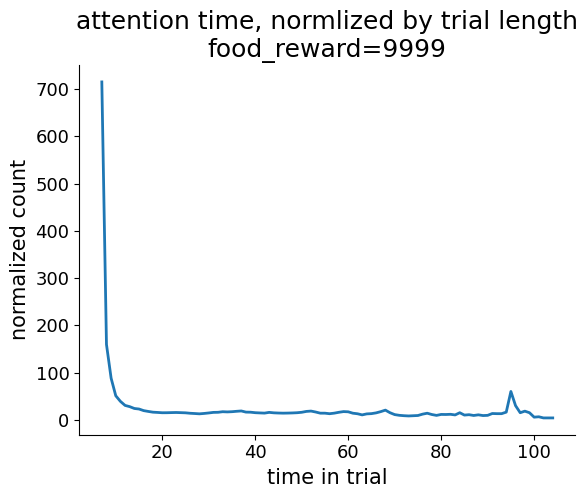

In [188]:
# added may1st, figure 6
for food_reward_idx in all_reward_res.keys():
    
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len=all_reward_res[food_reward_idx]

    data=att_time_list        
    padded=pad_zero_attention(data)
    trial_count_i=count_less_equal_index(trial_len)
    plt.figure()
    # plt.plot(np.sum(padded, axis=0)*np.cumsum(trial_count_i))
    # plt.plot(np.sum(padded, axis=0)/(trial_count_i))
    plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)))
    plt.xlabel('time in trial')
    plt.ylabel('normalized count')
    plt.title(f'attention time, normlized by trial length\nfood_reward={food_reward_list[food_reward_idx]:.0f}')
    plt.show()

/home/yc/miniconda3/envs/ffneural/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


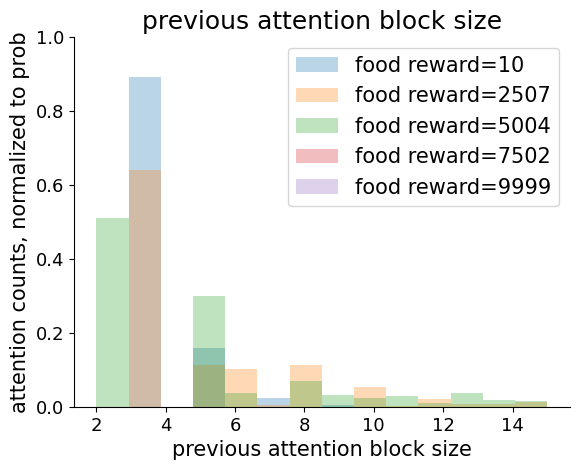

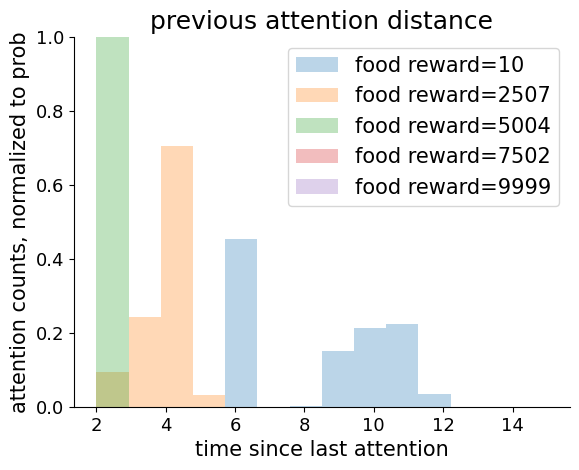

In [189]:
# figure 7
for food_reward_idx, v in all_reward_res.items():
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len=v
    att_size_previous=[previous_block_size(a) for a in att_time_list]
    a=np.concatenate(att_size_previous)
    plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=True,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
    # sns.kdeplot(a, fill=False, bw_adjust=0.5)
plt.ylim(0,1)
plt.title('previous attention block size')
plt.ylabel('attention counts, normalized to prob')
plt.xlabel('previous attention block size')
plt.legend()
plt.show()

for food_reward_idx, v in all_reward_res.items():
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len=v
    att_gap2previous=[previous_item_gap(a) for a in att_time_list]
    a=np.concatenate(att_gap2previous)
    plt.hist(a, bins=np.linspace(2,15,15), alpha=0.3, density=True,label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
    # sns.kdeplot(a, fill=False, bw_adjust=0.5)
plt.ylim(0,1)
plt.title('previous attention distance')
plt.ylabel('attention counts, normalized to prob')
plt.xlabel('time since last attention')
plt.legend()
plt.show()

In [191]:
np.concatenate(att_gap2previous).shape, np.concatenate(att_size_previous).shape

((19683,), (24061,))

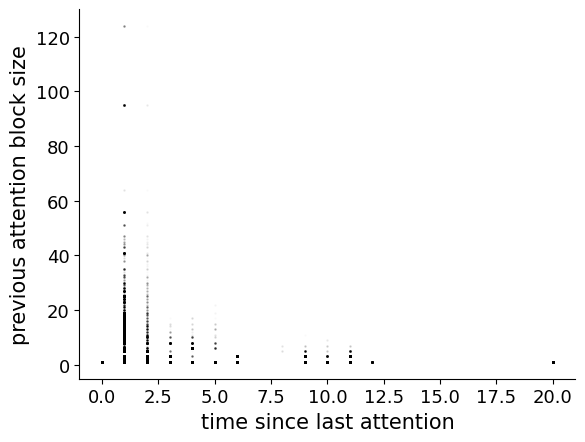

In [192]:
# fig 7 alt
for food_reward_idx, v in all_reward_res.items():
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len=v
    att_size_previous=[previous_block_size(a) for a in att_time_list]
    att_gap2previous=[previous_item_gap(a, remove_first=False) for a in att_time_list]
    plt.scatter(np.concatenate(att_gap2previous), np.concatenate(att_size_previous), alpha=0.01, s=1, color='k')
plt.ylabel('previous attention block size')
plt.xlabel('time since last attention')
plt.show()


# working space